# ML4T Library: Market Impact Models

**Docker image**: `ml4t`

This notebook demonstrates four **ml4t.backtest.execution** market-impact models and shows how
their signed price moves can be composed with an execution result:

1. **NoImpact**: Zero impact (baseline for comparison)
2. **LinearImpact**: Impact scales linearly with participation rate
3. **SquareRootImpact**: A volatility-scaled, concave baseline
4. **PowerLawImpact**: Generalized power law (configurable exponent)

**Key Benefits**:
- Consistent API across all models
- Explicit signed price moves for buy and sell orders
- Transparent composition with participation limits and execution results
- Research-motivated shapes with reader-visible parameter assumptions

**Learning Objectives**
- Compare the shapes implied by `NoImpact`, `LinearImpact`, `SquareRootImpact`,
  and `PowerLawImpact`
- Map the API surface to benchmark backtest execution code
- Interpret how participation and volatility drive impact cost
- Parameterize square-root impact with realized ETF volatility while holding the coefficient fixed

**Book Reference:** Chapter 18: Section 18.4 (Baseline Backtest Cost Models)

**Prerequisites:** Read
[`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for the economic meaning of
impact coefficients and
[`07_ml4t_volume_participation`](07_ml4t_volume_participation.ipynb) for quantity constraints per
bar.

## Imports & Setup

In [1]:
"""ML4T Library: Market Impact Models - Comparing impact model APIs for backtesting."""

from datetime import timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest.execution.impact import (
    LinearImpact,
    MarketImpactModel,
    NoImpact,
    PowerLawImpact,
    SquareRootImpact,
)
from ml4t.backtest.execution.limits import VolumeParticipationLimit
from ml4t.backtest.execution.result import ExecutionResult

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
SEED = 42

In [3]:
set_global_seeds(SEED)

## Part 1: Understanding the Impact Model API

All impact models inherit from `MarketImpactModel` and implement a single method:

```python
def calculate(
    self,
    quantity: float,    # Order quantity (shares)
    price: float,       # Current market price
    volume: float,      # Bar volume (daily, minute, etc.)
    is_buy: bool,       # Trade direction
) -> float:            # Signed per-share price move
```

The impact is a **signed per-share price move** (not bps): positive for buys and negative for
sells. Adding either signed move to the decision price worsens that side's execution. The absolute
value is the per-share cost magnitude.

`volume` must also respect decision timing. A completed bar's final volume is unavailable to a
pre-close decision; use known accumulated volume, a lagged or forecast volume, or execute on the
next bar. The examples below treat volume or ADV as an explicit scenario input.

In [4]:
# Instantiate all four models with default parameters
models = {
    "NoImpact": NoImpact(),
    "LinearImpact": LinearImpact(coefficient=0.1, permanent_fraction=0.5),
    "SquareRootImpact": SquareRootImpact(coefficient=0.5, volatility=0.02),
    "PowerLawImpact": PowerLawImpact(coefficient=0.1, exponent=0.5),
}

# Sample trade parameters
price = 100.0
volume = 1_000_000  # Daily volume
is_buy = True

# Impact (price units) at 1% / 5% / 10% participation, buying a $100 stock vs 1M ADV
impact_comparison = pl.DataFrame(
    [
        {
            "model": name,
            "impact_per_share_1pct_usd": model.calculate(volume * 0.01, price, volume, is_buy),
            "impact_per_share_5pct_usd": model.calculate(volume * 0.05, price, volume, is_buy),
            "impact_per_share_10pct_usd": model.calculate(volume * 0.10, price, volume, is_buy),
        }
        for name, model in models.items()
    ]
)
impact_comparison

model,impact_per_share_1pct_usd,impact_per_share_5pct_usd,impact_per_share_10pct_usd
str,f64,f64,f64
"""NoImpact""",0.0,0.0,0.0
"""LinearImpact""",0.1,0.5,1.0
"""SquareRootImpact""",0.1,0.223607,0.316228
"""PowerLawImpact""",1.0,2.236068,3.162278


**Finding**: Model levels are not comparable until their coefficients, volatility inputs, and
volume conventions are aligned. This table is an API and unit check; it shows how the illustrative
parameterizations differ rather than which model is most accurate.

## Part 2: Model Deep Dive

### LinearImpact

$$\text{Impact} = \text{coefficient} \times \frac{Q}{V} \times P$$

- Simple, intuitive model
- Good for liquid markets with moderate order sizes
- Parameters: `coefficient` (default 0.1), `permanent_fraction` (0-1)
- Current `calculate()` uses `coefficient` but does not use the stored `permanent_fraction`

In [5]:
# LinearImpact sensitivity analysis
linear = LinearImpact(coefficient=0.1)

participation_rates = np.linspace(0.001, 0.20, 100)
quantities = participation_rates * volume

linear_impacts = [linear.calculate(q, price, volume, is_buy) for q in quantities]
linear_10pct = linear.calculate(volume * 0.10, price, volume, is_buy)
linear_perm_zero = LinearImpact(coefficient=0.1, permanent_fraction=0.0).calculate(
    volume * 0.10, price, volume, is_buy
)
linear_perm_one = LinearImpact(coefficient=0.1, permanent_fraction=1.0).calculate(
    volume * 0.10, price, volume, is_buy
)
if not np.isclose(linear_perm_zero, linear_perm_one):
    raise AssertionError("Current LinearImpact.calculate() should ignore permanent_fraction.")

print(
    f"LinearImpact (coefficient={linear.coefficient}, "
    f"permanent_fraction={linear.permanent_fraction})"
)
print(f"  10% participation impact: ${linear_10pct:.4f} ({linear_10pct / price * 10000:.1f} bps)")

LinearImpact (coefficient=0.1, permanent_fraction=0.5)
  10% participation impact: $1.0000 (100.0 bps)


**Finding**: The linear model is useful as a baseline precisely because it is
easy to reason about. If its 10% ADV estimate already looks implausibly high or low, the notebook
has exposed a parameter problem before any backtest runs. In the current stateless API,
`permanent_fraction` is a stored but currently inert parameter; persistence must be supplied
outside `calculate()`.

### SquareRootImpact (Almgren-Chriss)

$$\text{Impact} = \text{coefficient} \times \sigma \times \sqrt{\frac{Q}{ADV}} \times P$$

- Common research-motivated baseline across asset classes
- Impact scales with square root of participation (concave)
- Incorporates volatility as a scaling factor
- Parameters: `coefficient` (library default 0.5), `volatility` (daily σ), `adv_factor`

In [6]:
# SquareRootImpact with different volatility regimes
sqrt_low_vol = SquareRootImpact(coefficient=0.5, volatility=0.01)
sqrt_mid_vol = SquareRootImpact(coefficient=0.5, volatility=0.02)
sqrt_high_vol = SquareRootImpact(coefficient=0.5, volatility=0.04)

sqrt_impacts_low = [sqrt_low_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_impacts_mid = [sqrt_mid_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_impacts_high = [sqrt_high_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_10pct_low = sqrt_low_vol.calculate(volume * 0.10, price, volume, is_buy)
sqrt_10pct_mid = sqrt_mid_vol.calculate(volume * 0.10, price, volume, is_buy)
sqrt_10pct_high = sqrt_high_vol.calculate(volume * 0.10, price, volume, is_buy)

print("SquareRootImpact (coefficient=0.5, illustrative library default)")
print(
    f"  10% participation @ 1% vol: ${sqrt_10pct_low:.4f} "
    f"({sqrt_10pct_low / price * 10000:.1f} bps)"
)
print(
    f"  10% participation @ 2% vol: ${sqrt_10pct_mid:.4f} "
    f"({sqrt_10pct_mid / price * 10000:.1f} bps)"
)
print(
    f"  10% participation @ 4% vol: ${sqrt_10pct_high:.4f} "
    f"({sqrt_10pct_high / price * 10000:.1f} bps)"
)

SquareRootImpact (coefficient=0.5, illustrative library default)
  10% participation @ 1% vol: $0.1581 (15.8 bps)
  10% participation @ 2% vol: $0.3162 (31.6 bps)
  10% participation @ 4% vol: $0.6325 (63.2 bps)


**Finding**: Volatility is not a cosmetic parameter. The same participation
rate becomes materially more expensive in a high-volatility regime, which is
why a volatility-parameterized scenario rises when the market becomes disorderly.

### PowerLawImpact

$$\text{Impact} = \text{coefficient} \times \left(\frac{Q}{V}\right)^{\text{exponent}} \times P$$

- Flexible model for different impact regimes
- `exponent=1.0` → Linear; `exponent=0.5` → Square root
- `0 < exponent < 1` → Concave (impact grows at a decreasing rate)
- `exponent>1` → Convex (impact grows at an increasing rate)
- `min_impact` is a minimum absolute per-share price move, not a fixed dollar trade cost

In [7]:
# PowerLawImpact with different exponents
power_linear = PowerLawImpact(coefficient=0.1, exponent=1.0)  # Same as LinearImpact
power_sqrt = PowerLawImpact(coefficient=0.1, exponent=0.5)
power_concave = PowerLawImpact(coefficient=0.1, exponent=0.3)
power_mild_concave = PowerLawImpact(coefficient=0.1, exponent=0.8)

power_impacts_linear = [power_linear.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_sqrt = [power_sqrt.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_concave = [power_concave.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_mild_concave = [
    power_mild_concave.calculate(q, price, volume, is_buy) for q in quantities
]
power_10pct_linear = power_linear.calculate(volume * 0.10, price, volume, is_buy)
power_10pct_sqrt = power_sqrt.calculate(volume * 0.10, price, volume, is_buy)
power_10pct_concave = power_concave.calculate(volume * 0.10, price, volume, is_buy)

print("PowerLawImpact (coefficient=0.1)")
print(f"  10% participation @ exp=1.0: ${power_10pct_linear:.4f} (linear)")
print(f"  10% participation @ exp=0.5: ${power_10pct_sqrt:.4f} (square root)")
print(f"  10% participation @ exp=0.3: ${power_10pct_concave:.4f} (strongly concave)")

PowerLawImpact (coefficient=0.1)
  10% participation @ exp=1.0: $1.0000 (linear)
  10% participation @ exp=0.5: $3.1623 (square root)
  10% participation @ exp=0.3: $5.0119 (strongly concave)


**Finding**: Every exponent between zero and one is concave; smaller exponents bend the curve
more strongly. For participation below one, a smaller exponent also raises the level when the
coefficient is held fixed, so curvature and coefficient must be chosen or estimated jointly.

## Part 3: Visual Comparison

The first chart compares the illustrative parameter sets used above. Its levels are not a model
ranking: `SquareRootImpact` includes volatility in its scale, while `PowerLawImpact` does not.

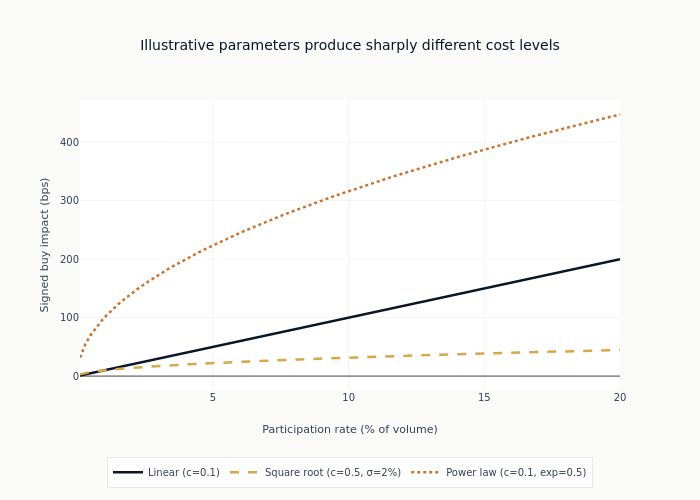

In [8]:
fig = go.Figure()
comparison_specs = (
    ("Linear (c=0.1)", linear_impacts, COLORS["blue"], "solid"),
    ("Square root (c=0.5, σ=2%)", sqrt_impacts_mid, COLORS["amber"], "dash"),
    ("Power law (c=0.1, exp=0.5)", power_impacts_sqrt, COLORS["copper"], "dot"),
)
for label, impacts, color, dash in comparison_specs:
    fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )
fig.update_layout(
    title="Illustrative parameters produce sharply different cost levels",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=500,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
fig.show()

**Finding**: Functional form alone does not rank cost severity. Here the exponent-0.5 power law
sits above the volatility-scaled square-root model because their coefficients use different
conventions, even though both curves have the same square-root shape.

### Volatility Sets Scale

Hold the square-root coefficient at the illustrative library default of 0.5 and vary only
volatility. A dedicated chart avoids implying that its y-scale is comparable to the power-law
coefficient convention.

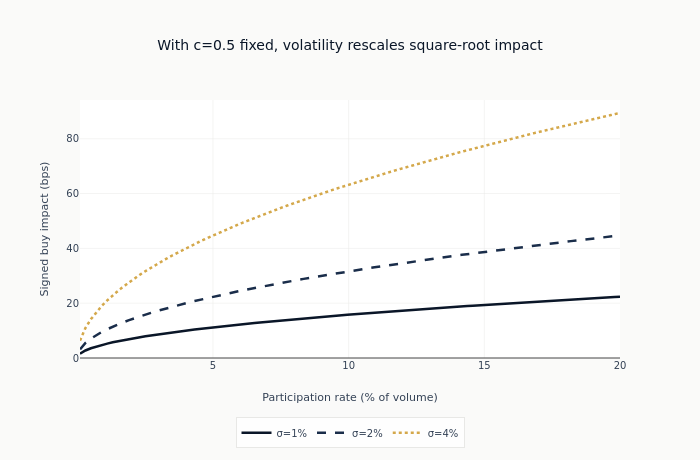

In [9]:
volatility_fig = go.Figure()
vol_specs = (
    ("σ=1%", sqrt_impacts_low, COLORS["blue"], "solid"),
    ("σ=2%", sqrt_impacts_mid, COLORS["slate"], "dash"),
    ("σ=4%", sqrt_impacts_high, COLORS["amber"], "dot"),
)
for label, impacts, color, dash in vol_specs:
    volatility_fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )
volatility_fig.update_layout(
    title="With c=0.5 fixed, volatility rescales square-root impact",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=460,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=100),
)
volatility_fig.update_yaxes(rangemode="tozero")
volatility_fig.show()

### The Exponent Sets Curvature

Now hold the power-law coefficient at 0.1. Exponents in the interval
$0 < \text{exponent} < 1$ are concave; 0.8 is mildly concave, not convex.

In [10]:
exponent_specs = (
    ("exp=1.0 (linear)", power_impacts_linear, COLORS["neutral"], "solid"),
    ("exp=0.8", power_impacts_mild_concave, COLORS["blue"], "dash"),
    ("exp=0.5", power_impacts_sqrt, COLORS["copper"], "dot"),
    ("exp=0.3", power_impacts_concave, COLORS["amber"], "dashdot"),
)
exponent_fig = go.Figure()
for label, impacts, color, dash in exponent_specs:
    exponent_fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )

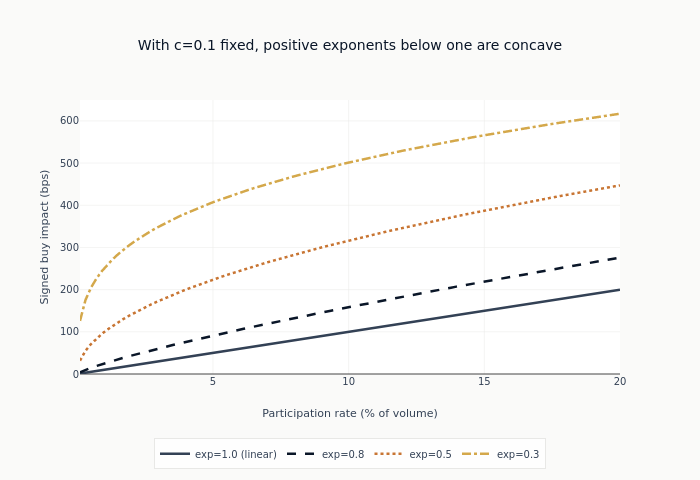

In [11]:
exponent_fig.update_layout(
    title="With c=0.1 fixed, positive exponents below one are concave",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=480,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
exponent_fig.update_yaxes(rangemode="tozero")
exponent_fig.show()

**Finding**: Doubling volatility doubles square-root impact at every participation rate. Changing
a positive exponent below one changes concavity, but a coefficient comparison is still required
before one shape can be called more expensive than another.

## Part 4: Trade Sequence Simulation

Compare models on an illustrative trade sequence: executing 100,000 shares of a $100 stock over
ten child orders. The impact objects are stateless, so the notebook adds a shared 50% persistence
scenario explicitly. This assumption is not state tracked by the library models.

In [12]:
# Trade sequence simulation
total_shares = 100_000
price = 100.0
adv_shares = 1_000_000
n_child_orders = 10
shares_per_order = total_shares / n_child_orders
persistence_fraction = 0.50

# Models to compare
simulation_models = {
    "NoImpact": NoImpact(),
    "LinearImpact": LinearImpact(coefficient=0.1),
    "SquareRootImpact": SquareRootImpact(coefficient=0.5, volatility=0.02),
    "PowerLawImpact": PowerLawImpact(coefficient=0.1, exponent=0.6),
}

### Simulate Multi-Order Execution

In [13]:
# Simulate execution
results = []
for model_name, model in simulation_models.items():
    exec_price = price
    total_cost = 0.0
    fill_prices = []

    for i in range(n_child_orders):
        # Each 10,000-share child is measured against the full 1,000,000-share ADV.
        impact = model.calculate(shares_per_order, exec_price, adv_shares, is_buy=True)

        # Fill at impacted price
        fill_price = exec_price + impact
        fill_prices.append(fill_price)

        # Cost for this fill
        order_cost = (fill_price - price) * shares_per_order
        total_cost += order_cost

        # Carry the stated scenario fraction into the next child order.
        exec_price = exec_price + impact * persistence_fraction

        results.append(
            {
                "model": model_name,
                "order": i + 1,
                "fill_price": fill_price,
                "impact_per_share_usd": impact,
                "cumulative_cost": total_cost,
            }
        )

results_df = pl.DataFrame(results)

### First-Child Unit Oracle

The first child is 10,000 shares against 1,000,000 ADV: exactly 1% participation. With linear
coefficient 0.1 and a $100 reference price, the signed buy move must be $0.10 per share, or 10 bps.

In [14]:
first_linear = results_df.filter((pl.col("model") == "LinearImpact") & (pl.col("order") == 1)).row(
    0, named=True
)
first_child_participation = shares_per_order / adv_shares
first_child_impact_per_share = first_linear["impact_per_share_usd"]
if not np.isclose(first_child_participation, 0.01):
    raise AssertionError("Each child order must represent 1% of full ADV.")
if not np.isclose(first_child_impact_per_share, 0.10):
    raise AssertionError("The first linear child impact must be $0.10 per share.")
display(
    Markdown(
        f"**Unit check:** first-child participation is **{first_child_participation:.0%}** and "
        f"linear impact is **${first_child_impact_per_share:.2f} per share** "
        f"(**{first_child_impact_per_share / price * 10_000:.0f} bps**)."
    )
)

**Unit check:** first-child participation is **1%** and linear impact is **$0.10 per share** (**10 bps**).

### Sequence-Level Cost Summary

In [15]:
# Sequence cost summary: 100,000 shares @ $100
sequence_summary_rows = []
for model_name in simulation_models.keys():
    model_data = results_df.filter(pl.col("model") == model_name)
    final_cost = model_data["cumulative_cost"][-1]
    sequence_summary_rows.append(
        {
            "model": model_name,
            "vwap_usd": price + final_cost / total_shares,
            "total_cost_usd": final_cost,
            "cost_bps": final_cost / (price * total_shares) * 10000,
        }
    )
sequence_summary = pl.DataFrame(sequence_summary_rows)
sequence_summary

model,vwap_usd,total_cost_usd,cost_bps
str,f64,f64,f64
"""NoImpact""",100.0,0.0,0.0
"""LinearImpact""",100.325526,32552.556292,32.552556
"""SquareRootImpact""",100.325526,32552.556292,32.552556
"""PowerLawImpact""",102.071654,207165.395752,207.165396


**Finding**: The sequence summary holds the parent order, child schedule, and assumed persistence
fixed. Differences therefore come from the illustrative model parameterizations, not from the
library maintaining cumulative state.

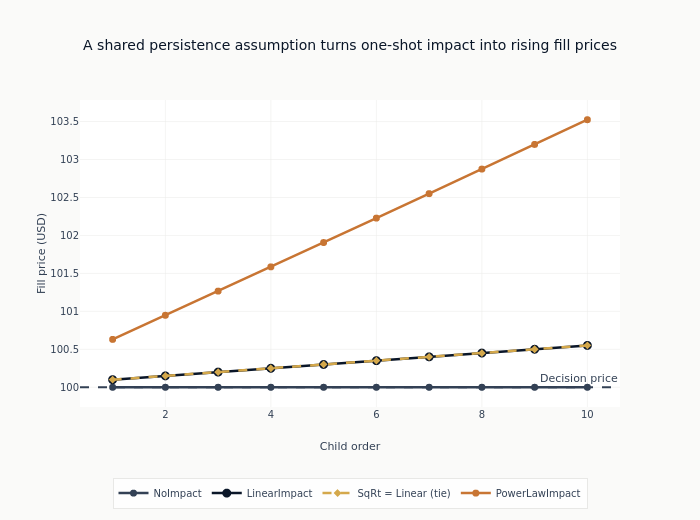

In [16]:
# Visualize execution paths
fig = go.Figure()
sequence_colors = {
    "NoImpact": COLORS["neutral"],
    "LinearImpact": COLORS["blue"],
    "SquareRootImpact": COLORS["amber"],
    "PowerLawImpact": COLORS["copper"],
}
sequence_dashes = {
    "NoImpact": "solid",
    "LinearImpact": "solid",
    "SquareRootImpact": "dash",
    "PowerLawImpact": "solid",
}
sequence_markers = {
    "NoImpact": (7, "circle"),
    "LinearImpact": (9, "circle"),
    "SquareRootImpact": (6, "diamond"),
    "PowerLawImpact": (7, "circle"),
}
linear_path = results_df.filter(pl.col("model") == "LinearImpact")["fill_price"]
square_root_path = results_df.filter(pl.col("model") == "SquareRootImpact")["fill_price"]
if not np.allclose(linear_path.to_numpy(), square_root_path.to_numpy()):
    raise AssertionError("Displayed parameters should make the two sequence paths tie exactly.")
for model_name in simulation_models:
    model_data = results_df.filter(pl.col("model") == model_name)
    marker_size, marker_symbol = sequence_markers[model_name]
    label = "SqRt = Linear (tie)" if model_name == "SquareRootImpact" else model_name
    fig.add_scatter(
        x=model_data["order"].to_list(),
        y=model_data["fill_price"].to_list(),
        mode="lines+markers",
        name=label,
        line=dict(width=2.5, color=sequence_colors[model_name], dash=sequence_dashes[model_name]),
        marker=dict(size=marker_size, symbol=marker_symbol),
    )

fig.add_hline(
    y=price,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="Decision price",
)

fig.update_layout(
    title="A shared persistence assumption turns one-shot impact into rising fill prices",
    xaxis_title="Child order",
    yaxis_title="Fill price (USD)",
    height=520,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
fig.show()

**Finding**: Under the stated 50% persistence scenario, repeated buy slices ratchet the reference
price upward. Linear and square-root paths tie under these parameters; a dashed, smaller square-root
overlay leaves the solid linear path visible. This demonstrates a scenario wrapper around stateless
impact models, not a permanent component supplied by every model class.

## Part 5: Backtest Integration Pattern

`FillExecutor` consumes the limit's `ExecutionResult` internally, uses its fillable quantity,
applies the signed impact once to the base price, applies slippage, and emits a `Fill` whose
`price` includes those adjustments. The limit result's `adjusted_price` and `impact_cost` remain
placeholders. The helper below exposes the intermediate limit-plus-impact arithmetic in an
`ExecutionResult`-shaped record for teaching; it is not the production executor's return value.

### Expose Limit-plus-Impact Arithmetic

In [17]:
def compose_limit_and_impact(
    quantity: float,
    side: str,
    decision_price: float,
    volume: float,
    impact_model: MarketImpactModel,
    max_participation: float = 0.10,
) -> ExecutionResult:
    """Expose one limit-plus-impact calculation in an inspection record."""
    if side not in {"buy", "sell"}:
        raise ValueError("side must be 'buy' or 'sell'")
    if volume <= 0:
        raise ValueError("volume must be positive")

    is_buy = side == "buy"
    limit_result = VolumeParticipationLimit(max_participation=max_participation).calculate(
        abs(quantity), volume, decision_price
    )
    fillable = limit_result.fillable_quantity
    remaining = limit_result.remaining_quantity

    impact = impact_model.calculate(
        quantity=fillable,
        price=decision_price,
        volume=volume,
        is_buy=is_buy,
    )
    adjusted_price = decision_price + impact
    return ExecutionResult(
        fillable_quantity=fillable,
        remaining_quantity=remaining,
        adjusted_price=adjusted_price,
        impact_cost=abs(impact) * fillable,
        participation_rate=limit_result.participation_rate,
    )

In [18]:
# Example: compare impact models on a series of orders
trades_data = [
    ("AAPL", 750_000, "buy", 175.0, 5_000_000),
    ("MSFT", 300_000, "buy", 380.0, 3_000_000),
    ("GOOGL", 225_000, "sell", 140.0, 1_500_000),
    ("NVDA", 200_000, "buy", 480.0, 4_000_000),
    ("META", 900_000, "sell", 350.0, 6_000_000),
]

**Finding**: This order list is intentionally small and heterogeneous so readers
can see how the same impact API scales across names, prices, and order sizes.

### Compare No-Impact vs Square-Root Impact

In [19]:
integration_rows = []
for model_name, impact_model in [
    ("NoImpact", NoImpact()),
    ("SquareRootImpact", SquareRootImpact(coefficient=0.5, volatility=0.02)),
]:
    for symbol, qty, side, decision_price, volume in trades_data:
        result = compose_limit_and_impact(qty, side, decision_price, volume, impact_model)
        integration_rows.append(
            {
                "model": model_name,
                "symbol": symbol,
                "side": side,
                "decision_price": decision_price,
                "fillable_qty": result.fillable_quantity,
                "remaining_qty": result.remaining_quantity,
                "is_partial": result.is_partial,
                "adjusted_price": result.adjusted_price,
                "participation_rate": result.participation_rate,
                "total_impact_cost_usd": result.impact_cost,
            }
        )

integration_results = pl.DataFrame(integration_rows)
integration_results

model,symbol,side,decision_price,fillable_qty,remaining_qty,is_partial,adjusted_price,participation_rate,total_impact_cost_usd
str,str,str,f64,f64,f64,bool,f64,f64,f64
"""NoImpact""","""AAPL""","""buy""",175.0,500000.0,250000.0,true,175.0,0.1,0.0
"""NoImpact""","""MSFT""","""buy""",380.0,300000.0,0.0,false,380.0,0.1,0.0
"""NoImpact""","""GOOGL""","""sell""",140.0,150000.0,75000.0,true,140.0,0.1,0.0
"""NoImpact""","""NVDA""","""buy""",480.0,200000.0,0.0,false,480.0,0.05,0.0
"""NoImpact""","""META""","""sell""",350.0,600000.0,300000.0,true,350.0,0.1,0.0
"""SquareRootImpact""","""AAPL""","""buy""",175.0,500000.0,250000.0,true,175.553399,0.1,276699.295265
"""SquareRootImpact""","""MSFT""","""buy""",380.0,300000.0,0.0,false,381.201666,0.1,360499.653259
"""SquareRootImpact""","""GOOGL""","""sell""",140.0,150000.0,75000.0,true,139.557281,0.1,66407.830864
"""SquareRootImpact""","""NVDA""","""buy""",480.0,200000.0,0.0,false,481.073313,0.05,214662.52584


### Verify Partial Fills and Adverse Direction

In [20]:
square_root_results = integration_results.filter(pl.col("model") == "SquareRootImpact")
partial_count = square_root_results.filter(pl.col("is_partial")).height
sell_direction_ok = (
    square_root_results.filter(pl.col("side") == "sell")
    .select((pl.col("adjusted_price") < pl.col("decision_price")).all())
    .item()
)
if not sell_direction_ok:
    raise AssertionError("Adverse sell impact must lower the adjusted price.")
display(
    Markdown(
        f"**Finding:** The 10% cap produces **{partial_count} partial orders** in this five-order "
        "scenario. Buy impact raises the adjusted price, sell impact lowers it, and absolute "
        "impact times filled quantity populates this teaching record's `impact_cost`."
    )
)

**Finding:** The 10% cap produces **3 partial orders** in this five-order scenario. Buy impact raises the adjusted price, sell impact lowers it, and absolute impact times filled quantity populates this teaching record's `impact_cost`.

## Part 6: Real-Data Volatility Parameterization

Without observed execution costs, this notebook cannot estimate an impact coefficient. It uses
the library's illustrative default of 0.5 and substitutes trailing realized volatility from five
ETFs. The result is descriptive parameterization, not empirical impact calibration.

### Load Canonical ETF Universe

In [21]:
etf_data = load_etfs()

symbols = ["SPY", "QQQ", "IWM", "EEM", "DBC"]

max_date = etf_data["timestamp"].max()
if max_date is None:
    raise ValueError("ETF dataset is empty; cannot parameterize impact models.")
min_date = max_date - timedelta(days=365)
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(symbols)) & (pl.col("timestamp") >= min_date)
)
missing_symbols = sorted(set(symbols) - set(etf_filtered["symbol"].unique().to_list()))
if missing_symbols:
    raise ValueError(f"Missing required ETF symbols: {missing_symbols}")

The five symbols are a fixed, retrospective teaching sample over the trailing 365 calendar days
in the dataset. They are not a point-in-time investment universe and support no holdout claim.

In [22]:
display(
    Markdown(
        f"The sample contains **{etf_filtered['symbol'].n_unique()} ETFs** from "
        f"**{etf_filtered['timestamp'].min():%Y-%m-%d}** through "
        f"**{etf_filtered['timestamp'].max():%Y-%m-%d}**."
    )
)

The sample contains **5 ETFs** from **2024-12-31** through **2025-12-31**.

### Compute Descriptive Inputs in Polars

Daily high-low range is a volatility proxy, not a quoted spread. The only input passed to the
square-root model below is the standard deviation of close-to-close returns.

In [23]:
etf_stats = (
    etf_filtered.sort(["symbol", "timestamp"])
    .with_columns(daily_return=pl.col("close").pct_change().over("symbol"))
    .group_by("symbol")
    .agg(
        observations=pl.len(),
        avg_price=pl.col("close").mean(),
        avg_volume=pl.col("volume").mean(),
        daily_volatility=pl.col("daily_return").std(),
        avg_high_low_range_bps=((pl.col("high") / pl.col("low") - 1) * 10_000).mean(),
    )
    .with_columns(annualized_volatility=pl.col("daily_volatility") * np.sqrt(252))
    .sort("symbol")
)
etf_stats

symbol,observations,avg_price,avg_volume,daily_volatility,avg_high_low_range_bps,annualized_volatility
str,u32,f64,f64,f64,f64,f64
"""DBC""",251,21.445646,872066.932271,0.009635,88.954374,0.152957
"""EEM""",251,47.492689,2.6052e7,0.011104,89.753988,0.17627
"""IWM""",251,221.74921,3.5313e7,0.014396,172.510733,0.228524
"""QQQ""",251,546.574928,4.8584e7,0.014865,151.624061,0.235971
"""SPY""",251,614.052782,7.2384e7,0.012275,119.279747,0.194867


The table separates observed descriptive inputs from assumed model parameters. Average volume
determines the share quantity represented by a participation rate; at a fixed rate, it cancels
from the model-implied bps calculation.

### Hold the Coefficient Fixed and Substitute Realized Volatility

In [24]:
impact_coefficient = SquareRootImpact().coefficient
participation_for_parameterization = 0.05
volatility_parameterized_models = {}

for row in etf_stats.iter_rows(named=True):
    symbol = row["symbol"]
    volatility_parameterized_models[symbol] = SquareRootImpact(
        coefficient=impact_coefficient,
        volatility=row["daily_volatility"],
        adv_factor=1.0,
    )

parameterized_impact_rows = []
for symbol, model in volatility_parameterized_models.items():
    stats = etf_stats.filter(pl.col("symbol") == symbol).row(0, named=True)
    asset_price = stats["avg_price"]
    asset_volume = stats["avg_volume"]
    quantity = asset_volume * participation_for_parameterization
    impact = model.calculate(quantity, asset_price, asset_volume, is_buy=True)
    parameterized_impact_rows.append(
        {
            "symbol": symbol,
            "daily_volatility": stats["daily_volatility"],
            "impact_per_share_usd": impact,
            "impact_bps": impact / asset_price * 10_000,
        }
    )
parameterized_impact = pl.DataFrame(parameterized_impact_rows).sort("impact_bps")

### Model-Implied Impact Mirrors the Volatility Input

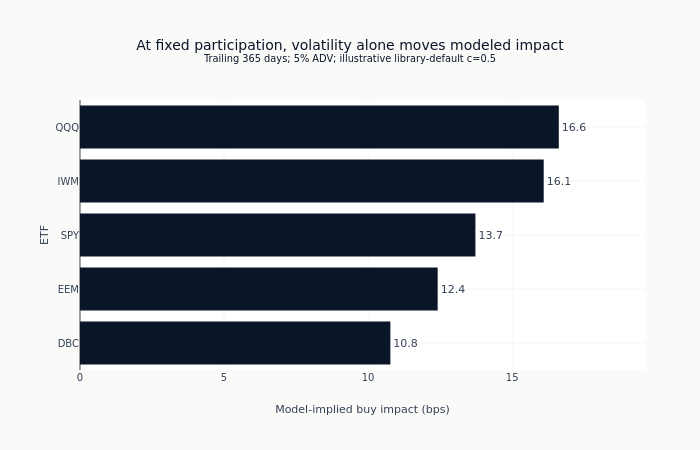

In [25]:
expected_bps = (
    impact_coefficient
    * parameterized_impact["daily_volatility"]
    * np.sqrt(participation_for_parameterization)
    * 10_000
)
if not np.allclose(parameterized_impact["impact_bps"].to_numpy(), expected_bps.to_numpy()):
    raise AssertionError("Square-root impact must reconcile to the closed-form bps calculation.")

impact_fig = go.Figure()
impact_fig.add_bar(
    x=parameterized_impact["impact_bps"].to_list(),
    y=parameterized_impact["symbol"].to_list(),
    orientation="h",
    marker_color=COLORS["blue"],
    text=[f"{value:.1f}" for value in parameterized_impact["impact_bps"]],
    textposition="outside",
)
impact_fig.update_layout(
    title=(
        "At fixed participation, volatility alone moves modeled impact"
        "<br><sup>Trailing 365 days; 5% ADV; illustrative library-default c=0.5</sup>"
    ),
    xaxis_title="Model-implied buy impact (bps)",
    yaxis_title="ETF",
    height=450,
    margin=dict(r=55),
)
impact_fig.update_xaxes(range=[0, parameterized_impact["impact_bps"].max() * 1.18])
impact_fig.show()

The closed-form expression provides an independent reconciliation and supports a computed reading
of the range rather than a hardcoded result.

In [26]:
lowest_impact = parameterized_impact.row(0, named=True)
highest_impact = parameterized_impact.row(-1, named=True)
display(
    Markdown(
        f"**Finding:** With coefficient {impact_coefficient:.1f} and 5% ADV fixed, modeled impact "
        f"ranges from **{lowest_impact['impact_bps']:.1f} bps** for {lowest_impact['symbol']} to "
        f"**{highest_impact['impact_bps']:.1f} bps** for {highest_impact['symbol']}. The difference "
        "comes only from trailing realized volatility, not price or average volume."
    )
)

**Finding:** With coefficient 0.5 and 5% ADV fixed, modeled impact ranges from **10.8 bps** for DBC to **16.6 bps** for QQQ. The difference comes only from trailing realized volatility, not price or average volume.

## Part 7: Cross-Model Impact at Increasing Order Sizes

To close, we use a separate synthetic $100 price and 1,000,000-share volume scenario, then tabulate
the impact each model implies from 1% to 20% participation. This section does not reuse the ETF
inputs. It is an assumption stress test, not a calibration result or evidence that one model is
correct.

In [27]:
# Summary comparison table
summary_data = []
reference_price = 100.0
reference_volume = 1_000_000.0

test_scenarios = [
    ("Small trade (1% ADV)", 0.01),
    ("Medium trade (5% ADV)", 0.05),
    ("Large trade (10% ADV)", 0.10),
    ("Very large (20% ADV)", 0.20),
]

test_models = {
    "NoImpact": NoImpact(),
    "Linear (0.1)": LinearImpact(coefficient=0.1),
    "SqRt (2% vol)": SquareRootImpact(coefficient=0.5, volatility=0.02),
    "Power (0.6)": PowerLawImpact(coefficient=0.1, exponent=0.6),
}

for scenario, participation in test_scenarios:
    row = {"Scenario": scenario}
    qty = reference_volume * participation

    for model_name, model in test_models.items():
        impact = model.calculate(qty, reference_price, reference_volume, is_buy=True)
        impact_bps = impact / reference_price * 10_000
        row[model_name] = f"{impact_bps:.1f} bps"

    summary_data.append(row)

summary_df = pl.DataFrame(summary_data)
summary_df

Scenario,NoImpact,Linear (0.1),SqRt (2% vol),Power (0.6)
str,str,str,str,str
"""Small trade (1% ADV)""","""0.0 bps""","""10.0 bps""","""10.0 bps""","""63.1 bps"""
"""Medium trade (5% ADV)""","""0.0 bps""","""50.0 bps""","""22.4 bps""","""165.7 bps"""
"""Large trade (10% ADV)""","""0.0 bps""","""100.0 bps""","""31.6 bps""","""251.2 bps"""
"""Very large (20% ADV)""","""0.0 bps""","""200.0 bps""","""44.7 bps""","""380.7 bps"""


**Finding**: The cross-model table keeps price, volume, and participation identical. Its level
differences therefore reflect model assumptions and parameter conventions, which should be
stress-tested rather than mistaken for observed execution costs.

## Key Takeaways

1. **One signed API across models**: `calculate(quantity, price, volume, is_buy)` returns a
   positive buy move and a negative sell move. Add either signed move to the decision price exactly
   once; the result is worse for the corresponding side.

2. **Shape and scale are separate choices**: every exponent between zero and one is concave, but
   coefficients and volatility conventions determine the cost level. The sequence simulation
   adds its 50% persistence assumption outside the stateless model classes.

3. **Volatility substitution is not calibration**: the ETF section holds the coefficient fixed
   and changes only realized volatility. Estimating the coefficient requires observed execution
   costs or another external target.

4. **Production emits impacted fills**: `FillExecutor` consumes a volume-limit result, adjusts the
   base price once for signed impact, then emits a `Fill`. The notebook helper exposes that
   intermediate arithmetic; `ExecutionResult.adjusted_price` and `impact_cost` remain placeholders.

5. **Volume is time-sensitive**: completed-bar volume cannot size a pre-close order. Use known,
   lagged, or forecast volume, or move execution to the next bar.

**Next**: `07_ml4t_volume_participation` for per-bar quantity constraints and
`10_gross_vs_net_performance` for full backtest integration; Section 18.7 covers TCA and model
validation.